In [1]:
import sys
sys.path.append("../src")

from preprocessing import run_preprocessing_pipeline
from cohort import approximate_retention_proxy, segment_retention_comparison
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = run_preprocessing_pipeline(config_path="../config/config.yaml")
df.head()

로드 완료: 3024행 x 13열
전처리 완료. 경로: ../data/processed/processed_data.csv


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,HasPurchased,is_whale,session_bin,age_group
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,1,0,6-10,45-54
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,1,0,11-20,13-17
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,1,0,6-10,18-24
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,1,0,11-20,25-34
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,1,0,6-10,35-44


In [3]:
retention_proxy = approximate_retention_proxy(df, retention_days=[1, 7, 30])
retention_proxy

day_1_purchase_retention_proxy_pct      5.59
day_7_purchase_retention_proxy_pct     23.28
day_30_purchase_retention_proxy_pct    95.50
dtype: float64

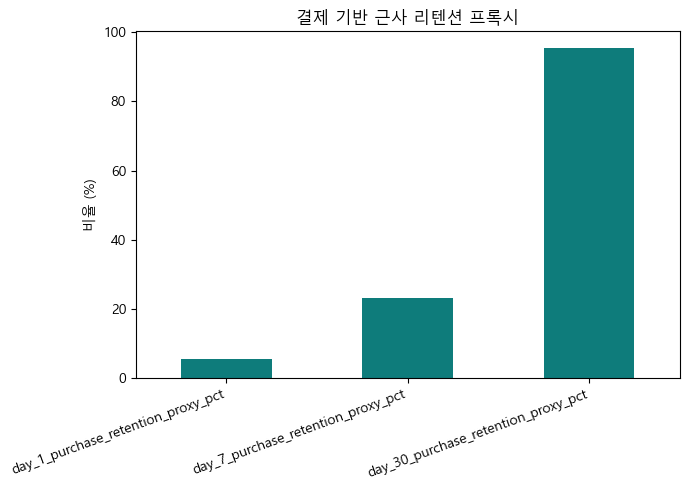

In [4]:
retention_proxy.plot(kind="bar", color="#0E7C7B", figsize=(7, 5))
plt.title("결제 기반 근사 리텐션 프록시")
plt.ylabel("비율 (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [5]:
seg_retention = segment_retention_comparison(df, "SpendingSegment")
seg_retention

,mean,median,count
SpendingSegment,,,
Dolphin,15.8,15.0,392
Minnow,15.3,16.0,2433
Whale,16.4,18.0,63


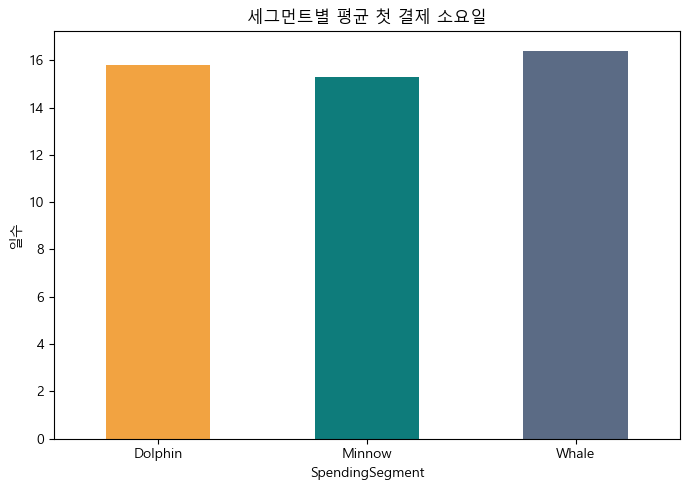

In [6]:
seg_retention["mean"].plot(kind="bar", color=["#F2A341", "#0E7C7B", "#5B6B85"], figsize=(7, 5))
plt.title("세그먼트별 평균 첫 결제 소요일")
plt.ylabel("일수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()